In [1]:
pip install "kagglehub[pandas-datasets]"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "amz_uk_price_prediction_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "asaniczka/uk-optimal-product-price-prediction",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/var/folders/4l/b_0rc2w95793857pgt7970wm0000gn/T/ipykernel_25437/2350940230.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    uid        asin                                              title  stars  \
0    1  B09B96TG33  Echo Dot (5th generation, 2022 release) | Big ...    4.7   
1    2  B01HTH3C8S  Anker Soundcore mini, Super-Portable Bluetooth...    4.7   
2    3  B09B8YWXDF  Echo Dot (5th generation, 2022 release) | Big ...    4.7   
3    4  B09B8T5VGV  Echo Dot with clock (5th generation, 2022 rele...    4.7   
4    5  B09WX6QD65  Introducing Echo Pop | Full sound compact Wi-F...    4.6   

   reviews  price  isBestSeller  boughtInLastMonth        category  
0    15308  21.99         False                  0  Hi-Fi Speakers  
1    98099  23.99          True                  0  Hi-Fi Speakers  
2    15308  21.99         False                  0  Hi-Fi Speakers  
3     7205  31.99         False                  0  Hi-Fi Speakers  
4     1881  17.99         False                  0  Hi-Fi Speakers  


In [3]:
print(df.shape)
print(df.columns.tolist())
df.head()

(2443651, 9)
['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller', 'boughtInLastMonth', 'category']


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [4]:
print(df.columns.tolist())

['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller', 'boughtInLastMonth', 'category']


In [8]:
# Part 1:

df.columns.tolist()

cat_col = 'category'
price_col = 'price'
rating_col = 'stars'

Top 5 categories:
category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


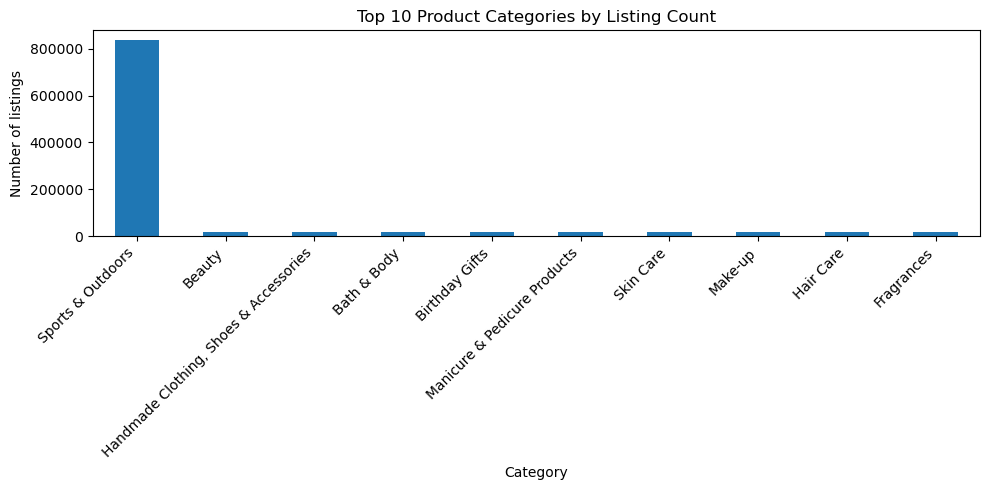

In [10]:
# Part 1 - Frequency Table

category_counts = df[cat_col].value_counts()

print("Top 5 categories:")
print(category_counts.head(5))

top10 = category_counts.head(10)
plt.figure(figsize=(10,5))
top10.plot(kind='bar')
plt.xlabel('Category')
plt.ylabel('Number of listings')
plt.title('Top 10 Product Categories by Listing Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# Part 1: Top 5 most listed product categories

category_counts = df[cat_col].value_counts()
print("Top 5 categories:")
print(category_counts.head(5))

Top 5 categories:
category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


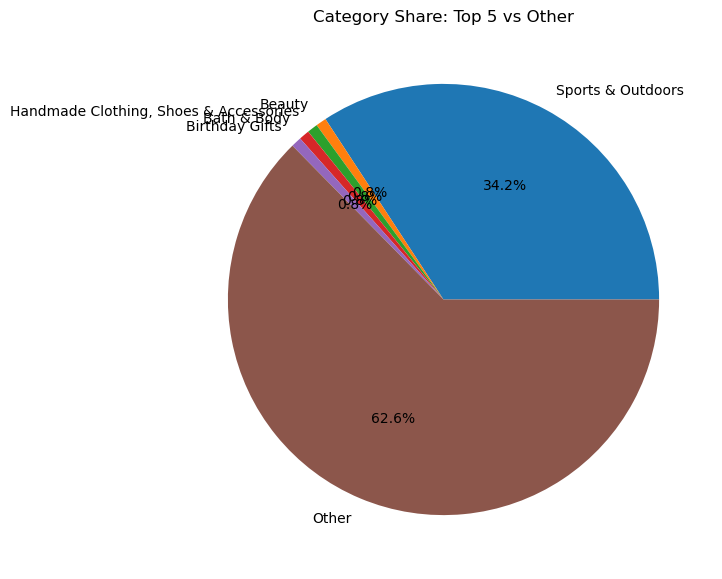

In [22]:
#Part 1: Pie Chart visualisation

top5 = category_counts.head(5)
other = category_counts.iloc[5:].sum()
pie_data = pd.concat([top5, pd.Series({'Other': other})])

plt.figure(figsize=(7,7))
pie_data.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Category Share: Top 5 vs Other')
plt.show()

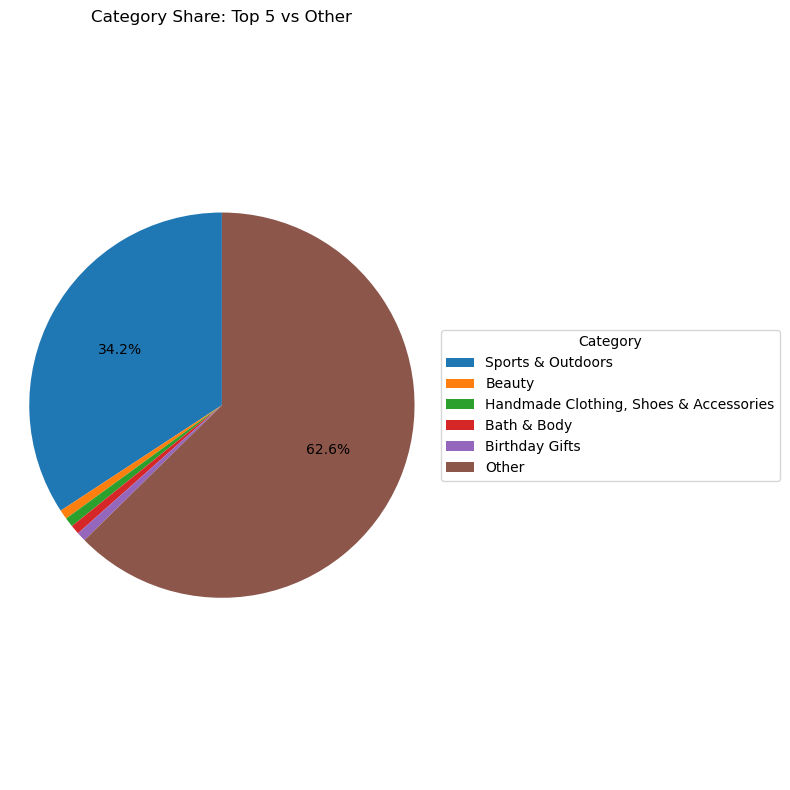

In [13]:
plt.figure(figsize=(8,8))

colors = plt.cm.tab10.colors  # a clean, distinct color set

wedges, texts, autotexts = plt.pie(
    pie_data,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',  # hide % label on tiny slices too
    colors=colors,
    startangle=90
)

plt.legend(
    wedges,
    pie_data.index,
    title="Category",
    loc="center left",
    bbox_to_anchor=(1, 0.5)  # places legend outside the pie, to the right
)

plt.title('Category Share: Top 5 vs Other')
plt.ylabel('')
plt.axis('equal')  # keeps the pie circular
plt.tight_layout()
plt.show()

In [15]:
#Part 2: Pricing

mean_price = df[price_col].mean()
median_price = df[price_col].median()
mode_price = df[price_col].mode()[0]

variance_price = df[price_col].var()
std_price = df[price_col].std()
range_price = df[price_col].max() - df[price_col].min()
q1, q3 = df[price_col].quantile(0.25), df[price_col].quantile(0.75)
iqr_price = q3 - q1

print(f"Mean: {mean_price:.2f}, Median: {median_price:.2f}, Mode: {mode_price:.2f}")
print(f"Variance: {variance_price:.2f}, Std: {std_price:.2f}, Range: {range_price:.2f}, IQR: {iqr_price:.2f}")

Mean: 89.24, Median: 19.09, Mode: 9.99
Variance: 119445.49, Std: 345.61, Range: 100000.00, IQR: 36.00


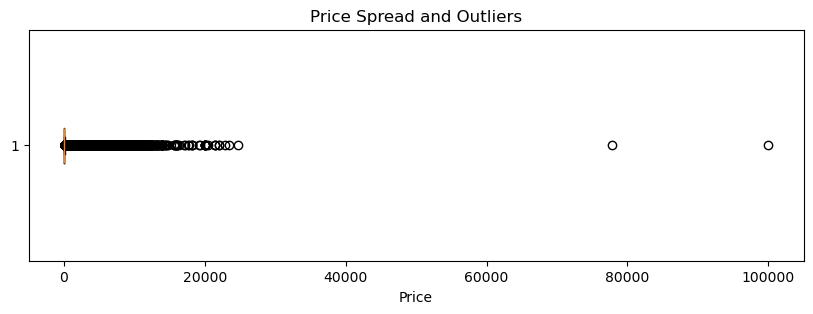

In [ ]:
plt.figure(figsize=(10,3))
plt.boxplot(df[price_col].dropna(), vert=False)
plt.xlabel('Price')
plt.title('Price Spread and Outliers')
plt.show()

In [ ]:
# PART 3: 

ratings_clean = df[rating_col].dropna()

mean_rating = ratings_clean.mean()
median_rating = ratings_clean.median()
mode_rating = ratings_clean.mode()[0]

variance_rating = ratings_clean.var()
std_rating = ratings_clean.std()
q1_r, q3_r = ratings_clean.quantile(0.25), ratings_clean.quantile(0.75)
iqr_rating = q3_r - q1_r

rating_skew = ratings_clean.skew()
rating_kurt = ratings_clean.kurt()

print(f"Mean: {mean_rating:.2f}, Median: {median_rating:.2f}, Mode: {mode_rating:.2f}")
print(f"Variance: {variance_rating:.3f}, Std: {std_rating:.3f}, IQR: {iqr_rating:.3f}")
print(f"Skewness: {rating_skew:.3f}, Kurtosis: {rating_kurt:.3f}")

Mean: 2.15, Median: 0.00, Mode: 0.00
Variance: 4.817, Std: 2.195, IQR: 4.400
Skewness: 0.081, Kurtosis: -1.926


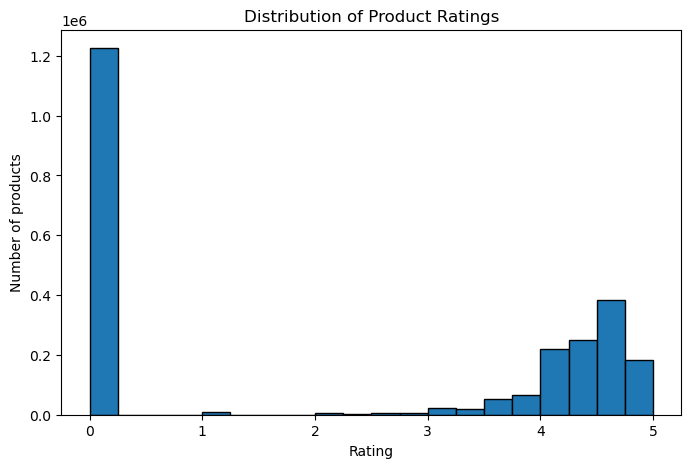

In [18]:
plt.figure(figsize=(8,5))
plt.hist(ratings_clean, bins=20, edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Number of products')
plt.title('Distribution of Product Ratings')
plt.show()

In [23]:
print("=== CATEGORIES ===")
category_counts = df[cat_col].value_counts()
print(category_counts.head(5))
print(f"Top 5 share: {category_counts.head(5).sum() / category_counts.sum() * 100:.1f}%")

print("\n=== PRICE ===")
print(f"Mean: {df[price_col].mean():.2f}")
print(f"Median: {df[price_col].median():.2f}")
print(f"Mode: {df[price_col].mode()[0]:.2f}")
print(f"Std: {df[price_col].std():.2f}")
print(f"Range: {df[price_col].max() - df[price_col].min():.2f}")
print(f"Max: {df[price_col].max():.2f}")
q1, q3 = df[price_col].quantile(0.25), df[price_col].quantile(0.75)
print(f"IQR: {q3 - q1:.2f}")

print("\n=== RATINGS ===")
r = df[rating_col].dropna()
print(f"Mean: {r.mean():.2f}")
print(f"Median: {r.median():.2f}")
print(f"Mode: {r.mode()[0]:.2f}")
q1r, q3r = r.quantile(0.25), r.quantile(0.75)
print(f"IQR: {q3r - q1r:.3f}")
print(f"Skewness: {r.skew():.3f}")
print(f"Kurtosis: {r.kurt():.3f}")

=== CATEGORIES ===
category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64
Top 5 share: 37.4%

=== PRICE ===
Mean: 89.24
Median: 19.09
Mode: 9.99
Std: 345.61
Range: 100000.00
Max: 100000.00
IQR: 36.00

=== RATINGS ===
Mean: 2.15
Median: 0.00
Mode: 0.00
IQR: 4.400
Skewness: 0.081
Kurtosis: -1.926


In [24]:
r = df[df[rating_col] > 0][rating_col]
print(f"Mean: {r.mean():.2f}, Median: {r.median():.2f}, Mode: {r.mode()[0]:.2f}")

Mean: 4.32, Median: 4.40, Mode: 4.50


In [25]:
r = df[df[rating_col] > 0][rating_col]

print(f"Std: {r.std():.3f}")
q1r, q3r = r.quantile(0.25), r.quantile(0.75)
print(f"IQR: {q3r - q1r:.3f}")
print(f"Skewness: {r.skew():.3f}")
print(f"Kurtosis: {r.kurt():.3f}")

Std: 0.555
IQR: 0.500
Skewness: -2.380
Kurtosis: 9.782


In [ ]:
"""
BUSINESS REPORT

## Part 1: Product Categories

The category distribution is heavily skewed: **Sports & Outdoors** alone accounts for 
836,265 listings — dramatically more than every other category combined. The next four 
categories (Beauty: 19,312; Handmade Clothing, Shoes & Accessories: 19,229; Bath & Body: 
19,092; Birthday Gifts: 18,978) are far smaller and fairly close to one another in size, 
together with the top category making up 37.4% of all listings.

**Caveat**: a single category outweighing the next-largest by roughly 40x is unusual enough 
to warrant a data quality check before drawing firm conclusions — it's possible some 
listings are defaulting to this category due to inconsistent tagging upstream, rather than 
this reflecting genuine market composition. If confirmed as real, it suggests Sports & 
Outdoors is Amazon UK's dominant listing category by a wide margin, while the next tier of 
categories are modest and fairly evenly matched in size.

## Part 2: Product Pricing

The average listed price is £89.24, but the median is only £19.09 and the mode is £9.99. 
The large gap between mean and median confirms heavy right-skew: a small number of very 
expensive products (max: £100,000) are dragging the average far above what a typical 
product actually costs. Most products are priced close to £10–£20.

This is reinforced by the dispersion figures: standard deviation is £345.61 and the full 
range is £100,000 — both driven almost entirely by extreme outliers — while the 
interquartile range (the middle 50% of products) spans just £36. This means the *typical* 
product's price varies relatively little, even though the overall spread looks enormous on 
paper.

**Business implication**: any pricing strategy referencing "the average price" (£89) would 
be misleading — the real, typical price point for Amazon UK products is closer to £10–£20. 
A small number of outlier high-priced listings (worth investigating individually — possibly 
also a data entry issue, since £100,000 is an extreme value for typical retail products) 
should not be allowed to skew strategic pricing decisions.

## Part 3: Product Ratings

**Note on data cleaning**: the raw `stars` column contained a large number of `0` values, 
which do not represent genuine 0-star ratings but rather products with no reviews yet 
(stored as `0` instead of missing). These were excluded before analysis, since including 
them would have misleadingly suggested customers rate products poorly (raw mean: 2.15) when 
in fact the opposite is true.

Among products with actual ratings, the average is **4.32 stars**, with a median of **4.40** 
and a mode of **4.50** — customers overwhelmingly rate products highly. The standard 
deviation is just **0.555**, and the interquartile range is only **0.500** stars, meaning 
the middle 50% of all rated products fall within a narrow half-star band. Ratings are 
remarkably consistent across the catalog rather than widely varied.

The shape of the distribution reinforces this: skewness of **-2.380** is strongly negative, 
confirming ratings lean heavily toward the high end, with a long thin tail stretching down 
toward lower scores (a relatively small number of poorly-rated products, not a mirror image 
of the high end). Kurtosis of **9.782** is sharply positive — far higher than a normal 
distribution's 0 — meaning ratings are tightly peaked around a common high value, with more 
extreme outliers on the low end than a normal spread would predict.

**Business implication**: since the overwhelming majority of listed products are rated 
4–5 stars, a rating alone provides little competitive differentiation between similar 
products — most competitors already clear this bar. The small tail of low-rated outliers 
is where the real signal is: these products likely represent genuine quality or fulfillment 
problems worth investigating individually, since they stand out precisely because they're 
so rare in this distribution.

## Business Summary & Recommendations

1. **Category strategy**: Sports & Outdoors dominates listings (836,265 products), 
   dramatically outweighing every other category — worth verifying this isn't a data 
   tagging artifact before treating it as a strategic signal. If genuine, it indicates 
   intense competition in that space, while the next tier of categories (Beauty, Handmade 
   Clothing, Bath & Body, Birthday Gifts — each ~19,000 listings) represent more balanced, 
   less saturated opportunities.

2. **Pricing strategy**: The average price (£89.24) is misleading — most products are 
   actually priced close to £10–£20 (median £19.09, mode £9.99), with a small number of 
   extreme outliers (up to £100,000) skewing the mean upward. A pricing strategy should 
   target this realistic £10–£36 typical range (the interquartile band) rather than the 
   inflated average, and treat the extreme high-price listings as a separate premium 
   segment — or flag them for data quality review, since £100,000 is an extreme value for 
   typical Amazon retail products.

3. **Ratings & trust**: Customer ratings cluster tightly and positively (mean 4.32, most 
   within half a star of each other), meaning rating alone won't differentiate a product 
   from its competitors — nearly everyone already scores well. The rare low-rated outliers 
   are the more actionable signal, worth investigating individually as likely genuine 
   quality issues rather than typical market variation.

**Data quality note**: both the ratings and category data required cleaning/scrutiny before 
being trustworthy for business conclusions — a reminder that raw platform data often encodes 
missing information as valid-looking numbers (0 ratings, extreme outlier prices), which can 
silently distort summary statistics if not caught early.

"""